                 Feature Name  Importance Score
10     avg_watch_time_minutes          0.091708
16  recommendation_click_rate          0.084739
13            completion_rate          0.081228
17      days_since_last_login          0.079210
3          account_age_months          0.079192
14               rating_given          0.076089
15       content_interactions          0.076083
0                         age          0.075037
11    watch_sessions_per_week          0.061350
12       binge_watch_sessions          0.057216
2                     country          0.048577
9              favorite_genre          0.043373
6              payment_method          0.029118
7              primary_device          0.028477
1                      gender          0.023105
8                devices_used          0.022528
5                 monthly_fee          0.022028
4           subscription_type          0.020940


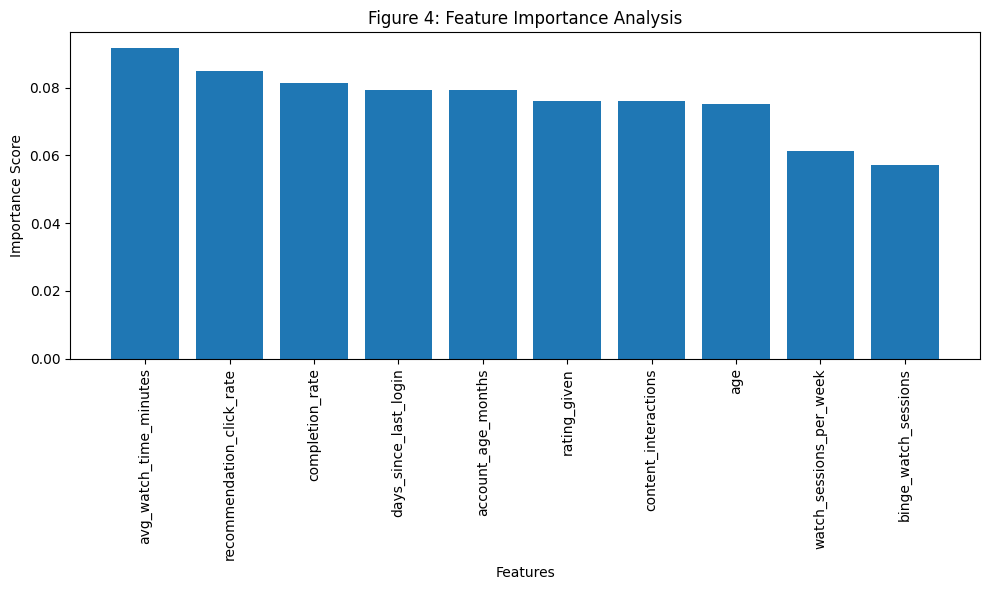

Saved: RQ4_table.csv and RQ4_figure.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/sampath1092003/netflix-user-behavior-analysis-dataset/netflix_user_behavior_dataset.csv"
)

# Drop user_id
df.drop("user_id", axis=1, inplace=True)

# Encode categorical variables
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("churned", axis=1)
y = df["churned"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

# Extract feature importance
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature Name": X.columns,
    "Importance Score": importance
})

# Sort values
feature_df = feature_df.sort_values(
    by="Importance Score",
    ascending=False
)

print(feature_df)

# Save table
feature_df.to_csv(
    "/kaggle/working/RQ4_table.csv",
    index=False
)

# Plot top 10 features
plt.figure(figsize=(10,6))

plt.bar(
    feature_df["Feature Name"][:10],
    feature_df["Importance Score"][:10]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Figure 4: Feature Importance Analysis")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/RQ4_figure.pdf"
)

plt.show()

print("Saved: RQ4_table.csv and RQ4_figure.pdf")